In [ ]:
from huggingface_hub import notebook_login
notebook_login()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
!git clone https://github.com/minwoosun/UCE.git

Cloning into 'UCE'...
remote: Enumerating objects: 151, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 151 (delta 66), reused 47 (delta 47), pack-reused 71 (from 1)
Receiving objects: 100% (151/151), 67.75 KiB | 6.16 MiB/s, done.
Resolving deltas: 100% (80/80), done.


In [ ]:
%cd UCE

/content/UCE


In [ ]:
! pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 59.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 156.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 169.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 146.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existin

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Upload dataset


## Run UCE model on loaded data

In [ ]:
import scanpy as sc

mouse_path = "content/Baron_Pancreas_Mouse.h5ad"


In [ ]:
adata_mouse = sc.read_h5ad(mouse_path)
print(adata_mouse)

AnnData object with n_obs × n_vars = 1868 × 10335
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch'


In [ ]:
! python eval_single_anndata.py --adata_path "/content/Baron_Pancreas_Mouse.h5ad" --dir "./"  --species "mouse" --model_loc "minwoosun/uce-100m"


Download Complete!
Proccessing Baron_Pancreas_Mouse
2398.0
Baron_Pancreas_Mouse (1868, 8826)
Wrote Shapes Dict
8826
Max Code: 715
config.json: 100% 115/115 [00:00<00:00, 839kB/s]
pytorch_model.bin: 100% 3.40G/3.40G [00:33<00:00, 101MB/s]
Loaded model:
minwoosun/uce-100m
100% 75/75 [00:35<00:00,  2.14it/s]
*****Wrote Anndata to:*****
./Baron_Pancreas_Mouse_uce_adata.h5ad


In [ ]:
# write embeddings to drive
import scanpy as sc
adata_mouse = sc.read_h5ad("/content/drive/MyDrive/GP_datasets/Pancreas/Embeddings/Pancreas_combined_Mouse_embeddings_uce.h5ad")
print(adata_mouse)


AnnData object with n_obs × n_vars = 1868 × 8826
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch', 'n_genes'
    var: 'n_cells'
    obsm: 'X_uce'


/tmp/ipykernel_957/3646110008.py:62: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_1.obs['y_pred_lr_kfold_mouse'] = pd.Series(y_pred_lr_kfold_mouse, index=adata_1.obs_names).astype(str).fillna('Unassigned')
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetric

=== Logistic Regression (k-fold) ===
Accuracy: 0.9480728051391863
                    precision    recall  f1-score   support

activated_stellate       1.00      0.14      0.25        14
             alpha       0.87      0.98      0.92       191
              beta       0.98      0.99      0.98       894
             delta       0.86      0.94      0.90       218
            ductal       0.97      1.00      0.98       275
       endothelial       0.98      0.99      0.98       139
             gamma       0.00      0.00      0.00        41
        macrophage       1.00      1.00      1.00        36
quiescent_stellate       0.80      0.96      0.87        47
           schwann       0.00      0.00      0.00         6
            t_cell       1.00      0.57      0.73         7

          accuracy                           0.95      1868
         macro avg       0.77      0.69      0.69      1868
      weighted avg       0.93      0.95      0.93      1868



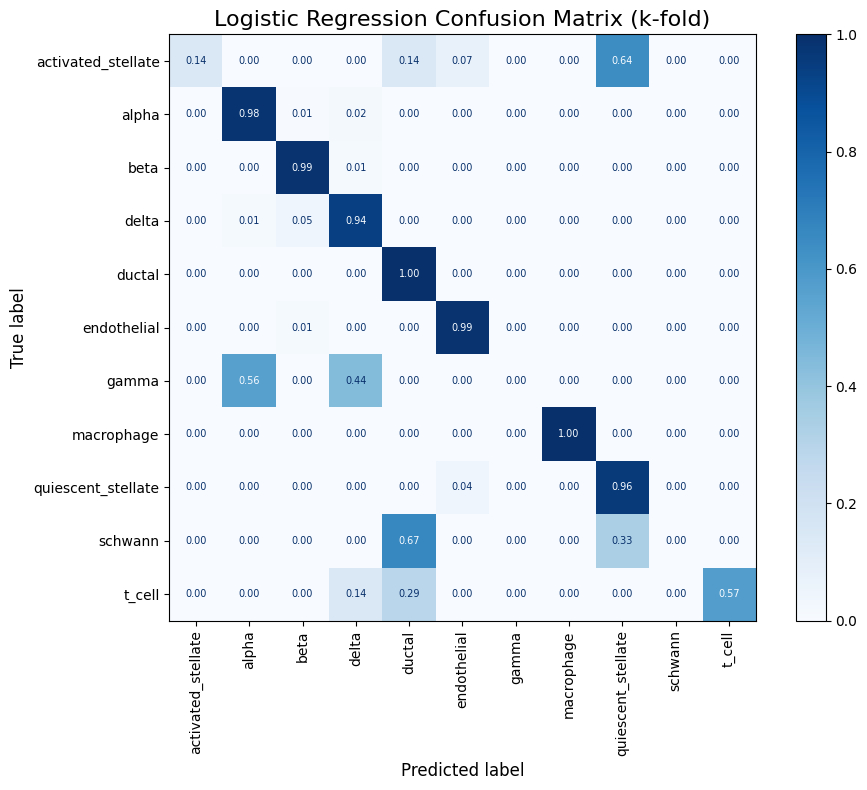


=== k-NN  (k-fold) ===
Accuracy: 0.9577087794432548
                    precision    recall  f1-score   support

activated_stellate       1.00      0.79      0.88        14
             alpha       0.84      0.96      0.90       191
              beta       0.99      0.99      0.99       894
             delta       0.89      0.93      0.91       218
            ductal       1.00      1.00      1.00       275
       endothelial       1.00      0.99      0.99       139
             gamma       0.71      0.12      0.21        41
        macrophage       1.00      1.00      1.00        36
quiescent_stellate       0.94      1.00      0.97        47
           schwann       1.00      0.83      0.91         6
            t_cell       1.00      0.86      0.92         7

          accuracy                           0.96      1868
         macro avg       0.94      0.86      0.88      1868
      weighted avg       0.96      0.96      0.95      1868



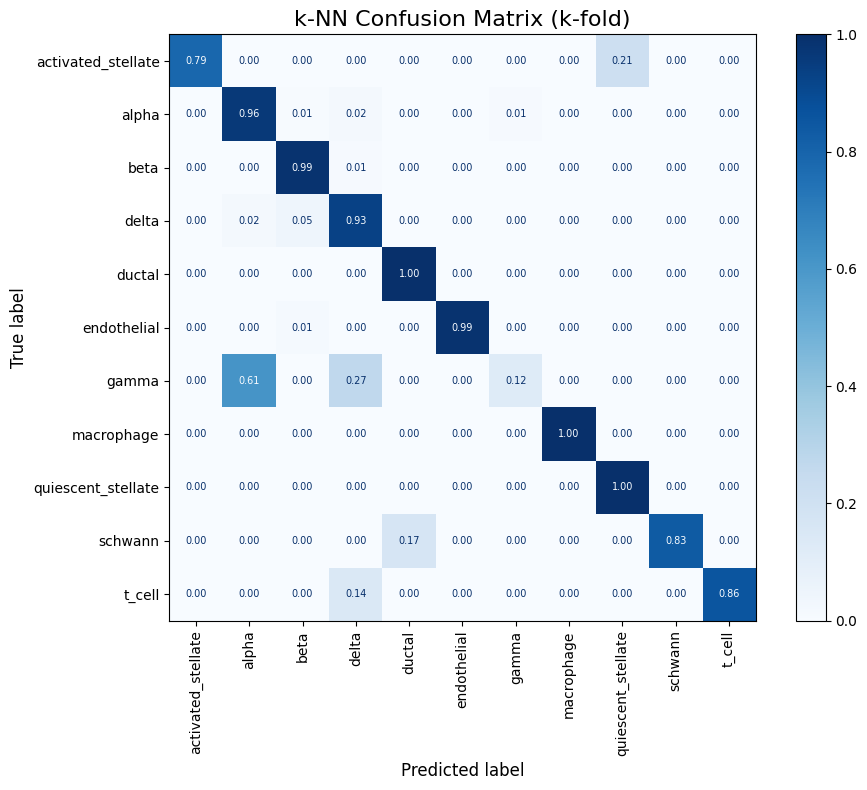

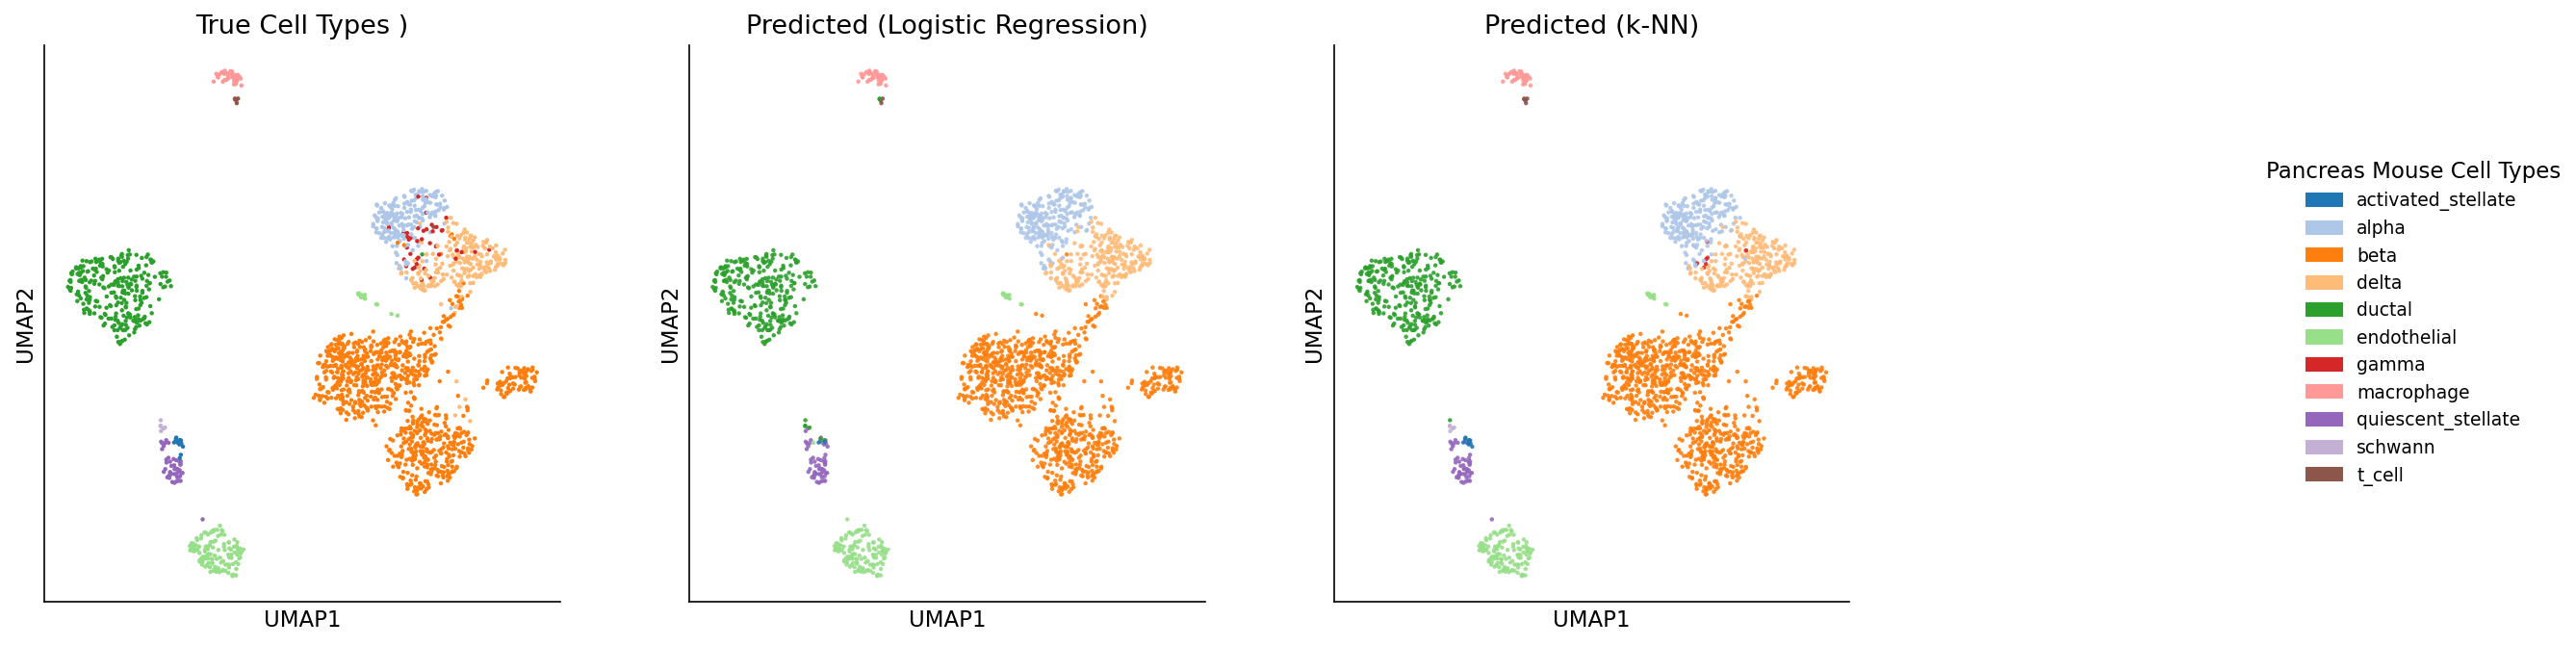

In [ ]:
## Build a cell-type classifier for regular annotation

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

#mouse data subset
adata_1 = adata[adata.obs["species"] == "mouse"]


# logistic regression with cross-validation

clf_kfold = LogisticRegression(max_iter=300, solver='lbfgs')

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
x_kfold = adata_1.obsm["X_uce"]
y_kfold = adata_1.obs["cell_type"]
y_pred_lr_kfold_mouse = cross_val_predict(clf_kfold, x_kfold , y_kfold, cv=kf)

# knn with cross-validation
from sklearn.neighbors import KNeighborsClassifier
# knn
# train
knn_kfold = KNeighborsClassifier(n_neighbors=15,
    weights="distance",
    metric="cosine")
knn_kfold.fit(x_kfold, y_kfold)
# test
y_pred_knn_kfold_mouse = cross_val_predict(knn_kfold, x_kfold , y_kfold, cv=kf)


def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

# Fill missing predicted labels
adata_1.obs['y_pred_lr_kfold_mouse'] = pd.Series(y_pred_lr_kfold_mouse, index=adata_1.obs_names).astype(str).fillna('Unassigned')
adata_1.obs['y_pred_knn_kfold_mouse'] = pd.Series(y_pred_knn_kfold_mouse, index=adata_1.obs_names).astype(str).fillna('Unassigned')



print("=== Logistic Regression (k-fold) ===")
print("Accuracy:", accuracy_score(y_kfold, y_pred_lr_kfold_mouse))
print(classification_report(y_kfold, y_pred_lr_kfold_mouse))
plot_cm(y_kfold, y_pred_lr_kfold_mouse, "Logistic Regression Confusion Matrix (k-fold)")


print("\n=== k-NN  (k-fold) ===")
print("Accuracy:", accuracy_score(y_kfold, y_pred_knn_kfold_mouse))
print(classification_report(y_kfold, y_pred_knn_kfold_mouse))
plot_cm(y_kfold, y_pred_knn_kfold_mouse, "k-NN Confusion Matrix (k-fold)")

sc.pp.neighbors(adata_1, use_rep="X_uce")
sc.tl.umap(adata_1)

# Combine all labels
all_labels = np.unique(np.concatenate([
    adata_1.obs["cell_type"].to_numpy(),
    adata_1.obs['y_pred_lr_kfold_mouse'].to_numpy(),
    adata_1.obs['y_pred_knn_kfold_mouse'].to_numpy()
]))

# Create consistent color map
palette = sc.pl.palettes.vega_20
label_to_color = {lbl: palette[i % len(palette)] for i, lbl in enumerate(all_labels)}
label_to_color['Unassigned'] = 'lightgray'

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(adata_1, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types )", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(adata_1, color="y_pred_lr_kfold_mouse", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(adata_1, color="y_pred_knn_kfold_mouse", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Pancreas Mouse Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()